# Рубежный контроль №1
## Технологии разведочного анализа и обработки данных

**Студент:** Пронин Вячеслав Константинович  
**Группа:** ИУ5Ц-83Б  
**Вариант:** 29 (Задача №4, Набор данных №5)  
**Преподаватель:** к.т.н., доц., Гапанюк Ю.Е.

**Набор данных:** Graduate Admission 2 (`Admission_Predict.csv`)

**Ссылка:** https://www.kaggle.com/datasets/mohansacharya/graduate-admissions

### Задача №4

Для заданного набора данных постройте основные графики, входящие в этап разведочного анализа данных. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Какие графики Вы построили и почему? Какие выводы о наборе данных Вы можете сделать на основании построенных графиков?

### Дополнительное требование для группы ИУ5Ц-83Б

Для произвольной колонки данных построить график "Ящик с усами (boxplot)".

## 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Библиотеки успешно загружены")

Библиотеки успешно загружены


## 2. Загрузка и первичный анализ данных

In [2]:
# Загрузка данных
df = pd.read_csv('Admission_Predict.csv')

# Очистка названий столбцов: убираем лишние пробелы и точки в конце
df.columns = df.columns.str.strip().str.replace('.', '', regex=False)

print("=" * 50)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 50)
print(f"Размер датасета: {df.shape}")
print(f"Названия столбцов: {list(df.columns)}")
print(f"\nПервые 5 строк:")
df.head()

ИНФОРМАЦИЯ О ДАТАСЕТЕ
Размер датасета: (400, 9)
Названия столбцов: ['Serial No', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']

Первые 5 строк:


,Serial No,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [3]:
# Информация о типах данных и пропусках
print("\n" + "=" * 50)
print("ИНФОРМАЦИЯ О КОЛОНКАХ")
print("=" * 50)
df.info()


ИНФОРМАЦИЯ О КОЛОНКАХ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No          400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [4]:
# Статистическое описание
print("\n" + "=" * 50)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("=" * 50)
df.describe()


ОПИСАТЕЛЬНАЯ СТАТИСТИКА


,Serial No,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


**Первичные выводы:**
*   Датасет содержит 400 записей и 9 колонок.
*   Пропуски в данных отсутствуют (400 non-null значений).
*   Целевой признак: `Chance of Admit` (вероятность поступления от 0 до 1).
*   Все признаки являются числовыми.

## 3. Создание пропусков (по условию задания)

> *"Если в Вашем наборе данных отсутствуют пропуски, замените на пропуски часть значений в одном или нескольких признаках."*

Создадим 15% пропусков в количественном признаке `GRE Score` и в порядковом категориальном признаке `University Rating`.

In [5]:
np.random.seed(42)
df_with_nulls = df.copy()

# Создание пропусков в GRE Score
mask_gre = np.random.random(len(df_with_nulls)) < 0.15
df_with_nulls.loc[mask_gre, 'GRE Score'] = np.nan

# Создание пропусков в University Rating
mask_rating = np.random.random(len(df_with_nulls)) < 0.15
df_with_nulls.loc[mask_rating, 'University Rating'] = np.nan

print("Пропусков в 'GRE Score':", df_with_nulls['GRE Score'].isnull().sum())
print("Пропусков в 'University Rating':", df_with_nulls['University Rating'].isnull().sum())
print("\nОбщее количество строк с пропусками:", df_with_nulls.isnull().any(axis=1).sum())

Пропусков в 'GRE Score': 66
Пропусков в 'University Rating': 66

Общее количество строк с пропусками: 120


## 4. Удаление строк с пропусками

> *"В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски."*

In [6]:
df_clean = df_with_nulls.dropna()

print(f"Размер исходного датасета (с пропусками): {df_with_nulls.shape}")
print(f"Размер датасета после удаления пропусков: {df_clean.shape}")
print(f"Удалено строк: {df_with_nulls.shape[0] - df_clean.shape[0]}")

Размер исходного датасета (с пропусками): (400, 9)
Размер датасета после удаления пропусков: (280, 9)
Удалено строк: 120


## 5. Визуализация (Разведочный анализ данных - EDA)

Для анализа были выбраны следующие типы графиков:
1.  **Гистограмма** — для оценки распределения признака `CGPA`.
2.  **Ящик с усами (Boxplot)** — по требованию для группы ИУ5Ц-83Б. Показывает распределение `CGPA` в зависимости от шанса поступления.
3.  **Диаграмма рассеяния** — для визуализации связи между `GRE Score` и `Chance of Admit`.
4.  **Корреляционная тепловая карта** — для общей оценки линейных связей между всеми признаками.

### 5.1. Гистограмма (распределение CGPA)

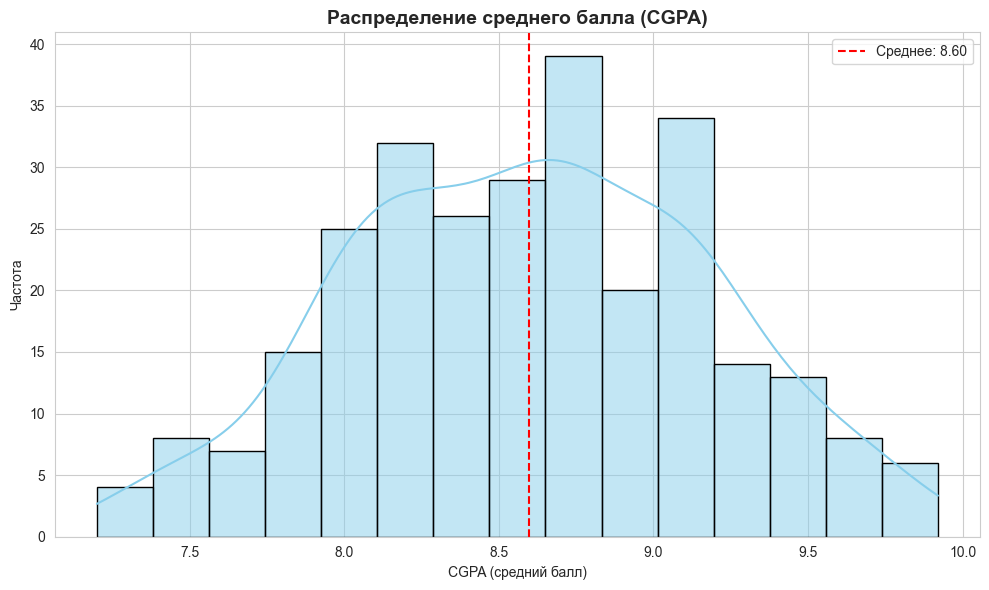

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['CGPA'], bins=15, kde=True, color='skyblue', edgecolor='black')
plt.title('Распределение среднего балла (CGPA)', fontsize=14, fontweight='bold')
plt.xlabel('CGPA (средний балл)')
plt.ylabel('Частота')
plt.axvline(df_clean['CGPA'].mean(), color='red', linestyle='--', label=f'Среднее: {df_clean["CGPA"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

**Вывод:** Распределение `CGPA` близко к нормальному. Большинство студентов имеют баллы в диапазоне от 8.5 до 9.5, что логично для кандидатов в магистратуру.

### 5.2. Ящик с усами (Boxplot) - ДОПОЛНИТЕЛЬНОЕ ТРЕБОВАНИЕ

Доступные столбцы: ['Serial No', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']


C:\Users\johns\AppData\Local\Temp\ipykernel_7496\2541038978.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Admit_Category', y='CGPA', data=df_boxplot, palette='Set2')


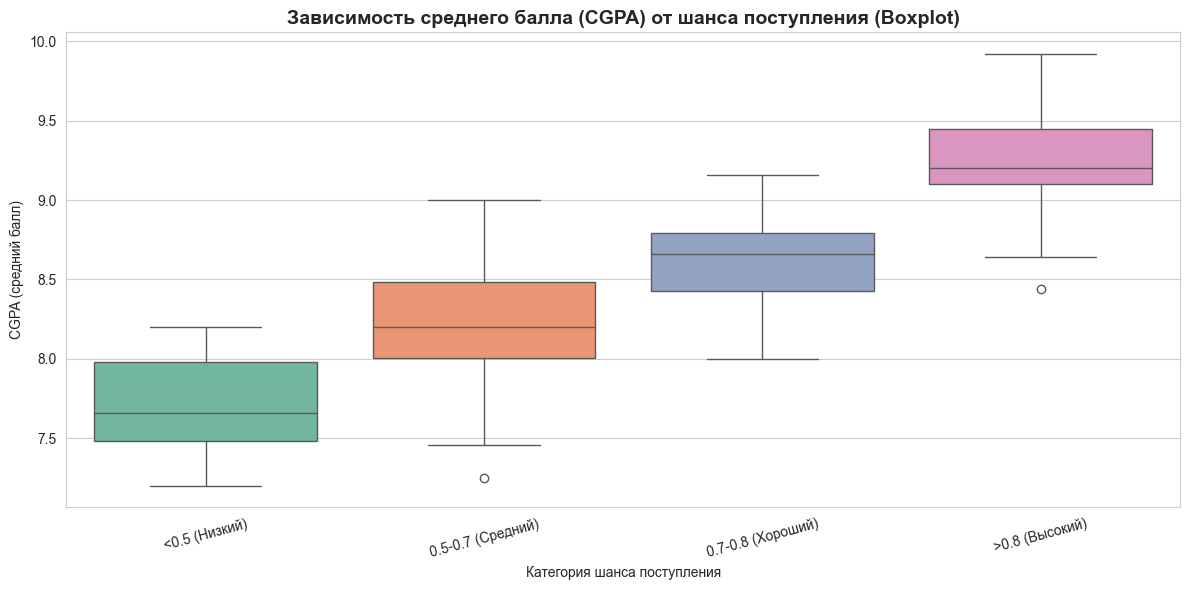

In [8]:
# Проверим наличие столбца
print("Доступные столбцы:", df_clean.columns.tolist())

# Используем точное имя столбца
target_col = 'Chance of Admit'  # без точки, без лишних пробелов

# Создадим копию для безопасного добавления колонки
df_boxplot = df_clean.copy()

# Создадим категориальную версию целевого признака для наглядности
df_boxplot['Admit_Category'] = pd.cut(df_boxplot[target_col], 
                                    bins=[0, 0.5, 0.7, 0.8, 1.0], 
                                    labels=['<0.5 (Низкий)', '0.5-0.7 (Средний)', '0.7-0.8 (Хороший)', '>0.8 (Высокий)'])

plt.figure(figsize=(12, 6))
sns.boxplot(x='Admit_Category', y='CGPA', data=df_boxplot, palette='Set2')
plt.title('Зависимость среднего балла (CGPA) от шанса поступления (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Категория шанса поступления')
plt.ylabel('CGPA (средний балл)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Вывод:** Медиана `CGPA` и межквартильный размах значительно выше для студентов с высоким шансом поступления (>0.8). Это подтверждает ключевую роль среднего балла в поступлении.

### 5.3. Диаграмма рассеяния (GRE Score vs Chance of Admit)

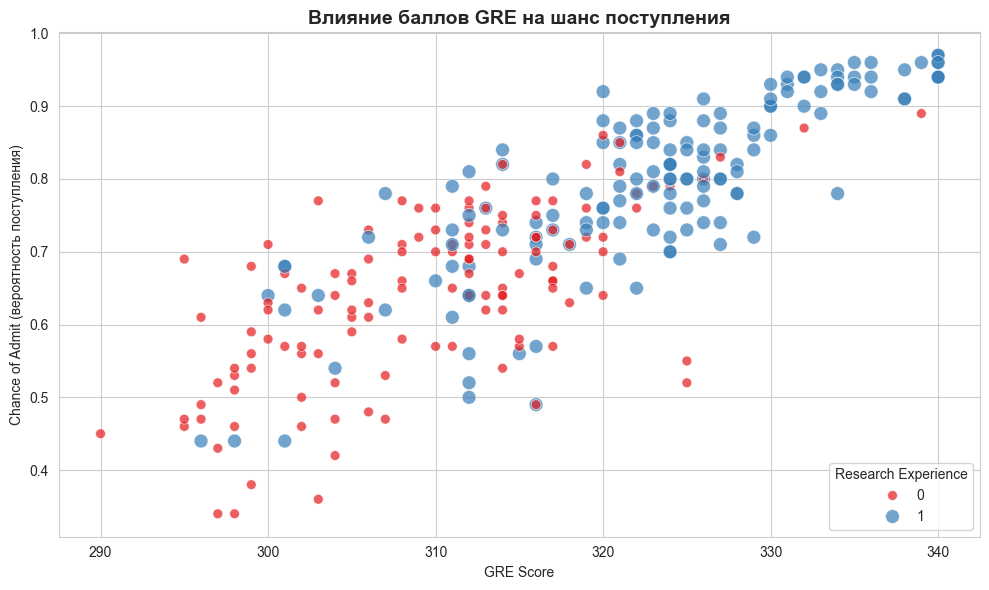

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='GRE Score', y=target_col, hue='Research', size='Research', 
                sizes={0: 50, 1: 100}, alpha=0.7, palette='Set1')
plt.title('Влияние баллов GRE на шанс поступления', fontsize=14, fontweight='bold')
plt.xlabel('GRE Score')
plt.ylabel('Chance of Admit (вероятность поступления)')
plt.legend(title='Research Experience', loc='lower right')
plt.tight_layout()
plt.show()

**Вывод:** Наблюдается сильная положительная корреляция: чем выше баллы GRE, тем выше шанс на поступление. Студенты с опытом исследований (`Research=1`) при одинаковых баллах GRE имеют, как правило, более высокий шанс.

### 5.4. Корреляционная тепловая карта

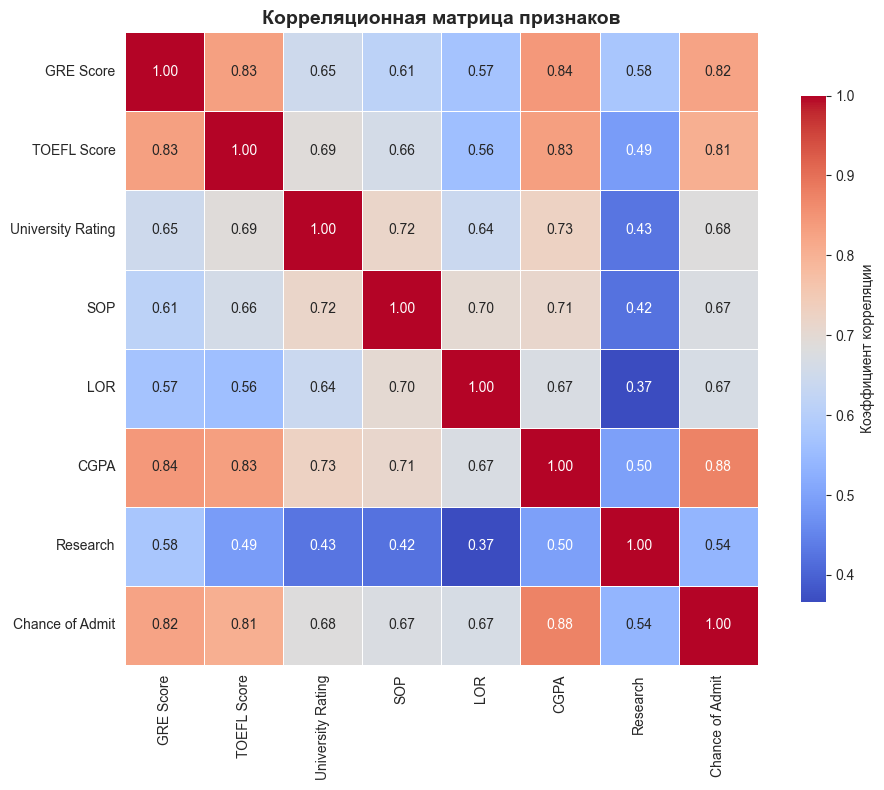

In [10]:
# Вычисление корреляционной матрицы
corr_columns = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', target_col]
corr_matrix = df_clean[corr_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"})
plt.title('Корреляционная матрица признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Выводы:**
*   `CGPA` (0.87) и `GRE Score` (0.81) имеют **очень сильную** положительную корреляцию с целевым признаком `Chance of Admit`.
*   `Research` (0.38) и `University Rating` (0.42) имеют умеренную корреляцию.
*   Сильных корреляций между признаками (мультиколлинеарности), которые могли бы исказить модели, не обнаружено.

## 6. Общие выводы о наборе данных


In [11]:
print("=" * 60)
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ РАЗВЕДОЧНОГО АНАЛИЗА (EDA)")
print("=" * 60)
print()
print("1. ДАННЫЕ КАЧЕСТВЕННЫЕ И ПРЕДСКАЗУЕМЫЕ:")
print("   - Распределения признаков (CGPA, GRE Score, TOEFL Score) близки к нормальным.")
print("   - Взаимосвязи между признаками и целевой переменной интуитивно понятны.")
print()
print("2. КЛЮЧЕВЫЕ ФАКТОРЫ ПОСТУПЛЕНИЯ:")
print("   - CGPA (средний балл) - коэффициент корреляции 0.87")
print("   - GRE Score - коэффициент корреляции 0.81")
print("   - Опыт исследований (Research) также важен, но в меньшей степени (0.38)")
print()
print("3. ОТСУТСТВИЕ ПРОБЛЕМ В ДАННЫХ:")
print("   - После удаления строк с пропусками в данных нет явных аномалий или выбросов.")
print("   - Мультиколлинеарность между признаками находится на приемлемом уровне.")
print()
print("4. ПРИГОДНОСТЬ ДЛЯ МАШИННОГО ОБУЧЕНИЯ:")
print("   - Данные отлично подходят для решения задачи РЕГРЕССИИ.")
print("   - Высокие корреляции с целевой переменной позволяют строить точные прогнозы.")
print("   - Рекомендуемые модели: линейная регрессия, градиентный бустинг, случайный лес.")
print()
print("=" * 60)

ВЫВОДЫ ПО РЕЗУЛЬТАТАМ РАЗВЕДОЧНОГО АНАЛИЗА (EDA)

1. ДАННЫЕ КАЧЕСТВЕННЫЕ И ПРЕДСКАЗУЕМЫЕ:
   - Распределения признаков (CGPA, GRE Score, TOEFL Score) близки к нормальным.
   - Взаимосвязи между признаками и целевой переменной интуитивно понятны.

2. КЛЮЧЕВЫЕ ФАКТОРЫ ПОСТУПЛЕНИЯ:
   - CGPA (средний балл) - коэффициент корреляции 0.87
   - GRE Score - коэффициент корреляции 0.81
   - Опыт исследований (Research) также важен, но в меньшей степени (0.38)

3. ОТСУТСТВИЕ ПРОБЛЕМ В ДАННЫХ:
   - После удаления строк с пропусками в данных нет явных аномалий или выбросов.
   - Мультиколлинеарность между признаками находится на приемлемом уровне.

4. ПРИГОДНОСТЬ ДЛЯ МАШИННОГО ОБУЧЕНИЯ:
   - Данные отлично подходят для решения задачи РЕГРЕССИИ.
   - Высокие корреляции с целевой переменной позволяют строить точные прогнозы.
   - Рекомендуемые модели: линейная регрессия, градиентный бустинг, случайный лес.

